In [55]:
import pandas as pd

columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installment_plans', 'housing',
    'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'risk'
]

df = pd.read_csv('german.data', sep=r'\s+', header=None, names=columns)
df['risk_label'] = df['risk'].map({1: 'Good (Low Risk)', 2: 'Bad (High Risk)'})

display(df.head())

,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,risk,risk_label
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,Good (Low Risk)
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,Bad (High Risk)
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,Good (Low Risk)
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,Good (Low Risk)
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,Bad (High Risk)


EXPLORATION

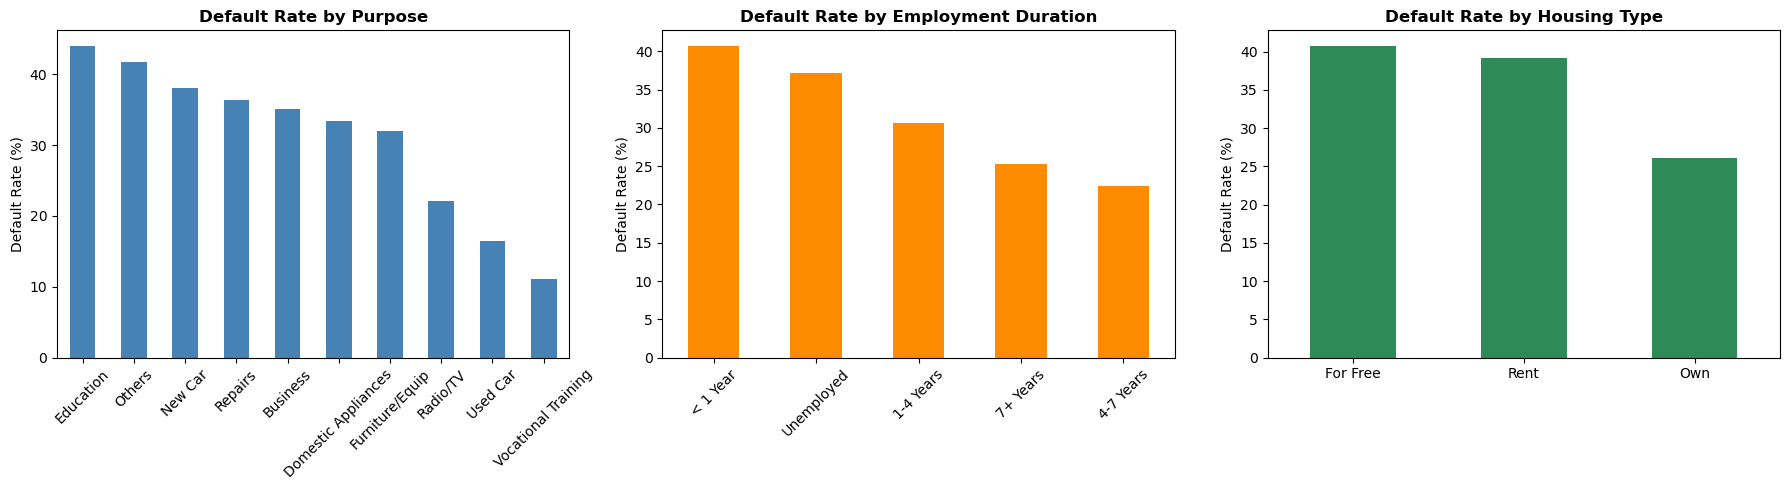

In [56]:
import matplotlib.pyplot as plt

purpose_map = {
    'A40': 'New Car',
    'A41': 'Used Car',
    'A42': 'Furniture/Equip',
    'A43': 'Radio/TV',
    'A44': 'Domestic Appliances',
    'A45': 'Repairs',
    'A46': 'Education',
    'A48': 'Vocational Training',
    'A49': 'Business',
    'A410': 'Others'
}

employment_map = {
    'A71': 'Unemployed',
    'A72': '< 1 Year',
    'A73': '1-4 Years',
    'A74': '4-7 Years',
    'A75': '7+ Years'
}

housing_map = {
    'A151': 'Rent',
    'A152': 'Own',
    'A153': 'For Free'
}

df_mapped = df.copy()
df_mapped['purpose'] = df_mapped['purpose'].map(purpose_map)
df_mapped['employment'] = df_mapped['employment'].map(employment_map)
df_mapped['housing'] = df_mapped['housing'].map(housing_map)

def default_rate(x):
    return (x == 'Bad (High Risk)').mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Purpose
purpose_rate = df_mapped.groupby('purpose')['risk_label'].apply(default_rate).sort_values(ascending=False)
purpose_rate.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Default Rate by Purpose', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)', fontsize=10)
axes[0].set_xlabel('')  # إخفاء كلمة purpose لتنظيف المظهر
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Employment Duration
employment_rate = df_mapped.groupby('employment')['risk_label'].apply(default_rate).sort_values(ascending=False)
employment_rate.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Default Rate by Employment Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)', fontsize=10)
axes[1].set_xlabel('')  # إخفاء كلمة employment
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Housing Type
housing_rate = df_mapped.groupby('housing')['risk_label'].apply(default_rate).sort_values(ascending=False)
housing_rate.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Default Rate by Housing Type', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Default Rate (%)', fontsize=10)
axes[2].set_xlabel('')  # إخفاء كلمة housing
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

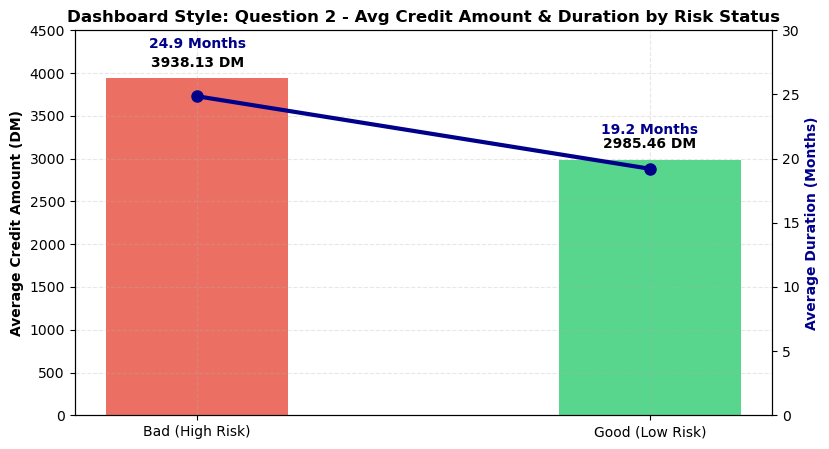

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

df_risk = df.groupby('risk_label').agg({
    'credit_amount': 'mean',
    'duration': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))

colors = ['#2ecc71' if r == 'Good (Low Risk)' else '#e74c3c' for r in df_risk['risk_label']]
bars = ax1.bar(df_risk['risk_label'], df_risk['credit_amount'], color=colors, alpha=0.8, width=0.4, label='Avg Credit Amount')
ax1.set_ylabel('Average Credit Amount (DM)', color='black', fontweight='bold')
ax1.set_ylim(0, 4500)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{yval:.2f} DM', ha='center', va='bottom', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(df_risk['risk_label'], df_risk['duration'], color='darkblue', marker='o', linewidth=3, markersize=8, label='Avg Duration (Months)')
ax2.set_ylabel('Average Duration (Months)', color='darkblue', fontweight='bold')
ax2.set_ylim(0, 30)
for i, txt in enumerate(df_risk['duration']):
    offset_y = 35 if i == 0 else 25
    
    ax2.annotate(f'{txt:.1f} Months', 
                 (df_risk['risk_label'][i], df_risk['duration'][i]), 
                 textcoords="offset points", 
                 xytext=(0, offset_y), 
                 ha='center', 
                 fontweight='bold', 
                 color='darkblue')

plt.title('Dashboard Style: Question 2 - Avg Credit Amount & Duration by Risk Status', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)

plt.show()

Detected Savings/Income Column: 'savings'
Overall Average Credit Amount: 3271.26
Number of Applicants in Q3: 204


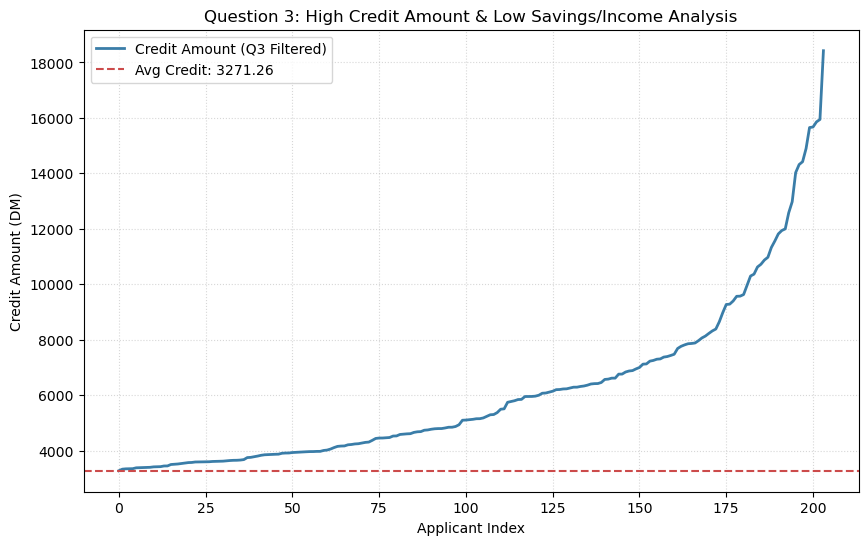

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

savings_col = [col for col in df.columns if 'sav' in col.lower() or 'inc' in col.lower()]
savings_column = savings_col[0] if savings_col else df.columns[0]
print(f"Detected Savings/Income Column: '{savings_column}'")

avg_credit = df['credit_amount'].mean()

if pd.api.types.is_numeric_dtype(df[savings_column]):
    avg_savings = df[savings_column].mean()
    q3_filtered_data = df[(df['credit_amount'] > avg_credit) & (df[savings_column] < avg_savings)]
else:
    
    q3_filtered_data = df[(df['credit_amount'] > avg_credit) & (df[savings_column].astype(str).str.lower().str.contains('little|low|1'))]

print(f"Overall Average Credit Amount: {avg_credit:.2f}")
print(f"Number of Applicants in Q3: {len(q3_filtered_data)}")

sorted_q3 = q3_filtered_data.sort_values(by='credit_amount').reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.plot(sorted_q3['credit_amount'], label='Credit Amount (Q3 Filtered)', color='#3a7da8', linewidth=2.0)

plt.axhline(avg_credit, color='#cc4b4b', linestyle='--', label=f'Avg Credit: {avg_credit:.2f}')

plt.title('Question 3: High Credit Amount & Low Savings/Income Analysis')
plt.ylabel('Credit Amount (DM)')
plt.xlabel('Applicant Index')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [59]:
import pandas as pd

mean_credit = df['credit_amount'].mean()
mean_duration = df['duration'].mean()

q3_filtered = df[(df['credit_amount'] > mean_credit) & (df['duration'] < mean_duration)]

print("--- Question 3 Results ---")
print(f"Overall Average Credit Amount: {mean_credit:.2f}")
print(f"Overall Average Duration: {mean_duration:.2f}")
print(f"Number of applicants matching the criteria: {len(q3_filtered)}")

display(q3_filtered[['purpose', 'credit_amount', 'duration', 'risk_label']].head(15))

--- Question 3 Results ---
Overall Average Credit Amount: 3271.26
Overall Average Duration: 20.90
Number of applicants matching the criteria: 87


,purpose,credit_amount,duration,risk_label
32,A40,5866,18,Good (Low Risk)
42,A45,6204,18,Good (Low Risk)
48,A40,7228,11,Good (Low Risk)
53,A41,3378,18,Good (Low Risk)
56,A43,6468,12,Bad (High Risk)
77,A43,4771,11,Good (Low Risk)
99,A41,7057,20,Good (Low Risk)
106,A40,6458,18,Bad (High Risk)
107,A40,6078,12,Good (Low Risk)
112,A40,6260,18,Good (Low Risk)


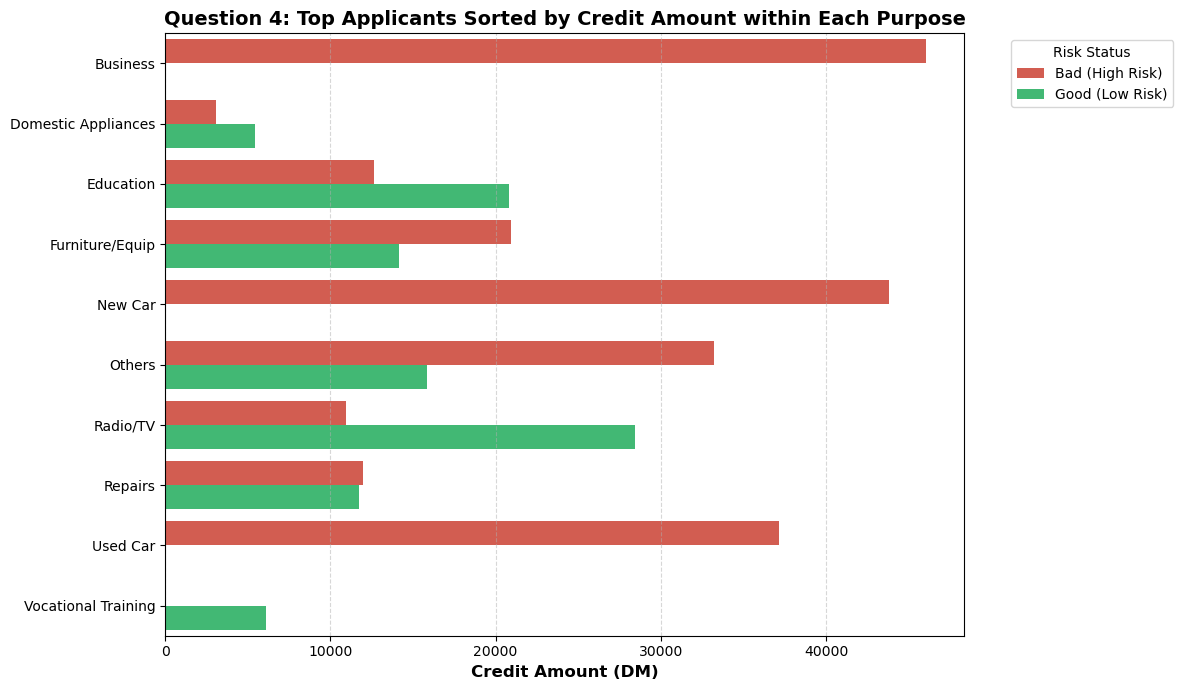

--- Question 4 Sorted Data Table ---


,purpose,credit_amount,duration,risk_label
95,Business,15945,54,Bad (High Risk)
887,Business,15672,48,Bad (High Risk)
63,Business,14421,48,Bad (High Risk)
615,Business,12204,48,Good (Low Risk)
832,Business,11816,45,Bad (High Risk)
684,Business,9857,36,Good (Low Risk)
180,Business,9572,36,Bad (High Risk)
402,Business,8648,24,Bad (High Risk)
491,Business,8318,27,Bad (High Risk)
17,Business,8072,30,Good (Low Risk)


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

purpose_map = {
    'A40': 'New Car',
    'A41': 'Used Car',
    'A42': 'Furniture/Equip',
    'A43': 'Radio/TV',
    'A44': 'Domestic Appliances',
    'A45': 'Repairs',
    'A46': 'Education',
    'A48': 'Vocational Training',
    'A49': 'Business',
    'A410': 'Others'
}

df_mapped = df.copy()
df_mapped['purpose'] = df_mapped['purpose'].map(purpose_map)

df_sorted_q4 = df_mapped.sort_values(by=['purpose', 'credit_amount'], ascending=[True, False])
top_applicants = df_sorted_q4.groupby('purpose').head(3).reset_index(drop=True)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_applicants,
    y='purpose',
    x='credit_amount',
    hue='risk_label',
    estimator=sum,
    errorbar=None,
    palette={
        'Good (Low Risk)': '#2ecc71',
        'Bad (High Risk)': '#e74c3c'
    }
)

plt.title('Question 4: Top Applicants Sorted by Credit Amount within Each Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Credit Amount (DM)', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12) 
plt.legend(title='Risk Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- Question 4 Sorted Data Table ---")
display(df_sorted_q4[['purpose', 'credit_amount', 'duration', 'risk_label']].head(15))

--- جدول نسبة التخلف لكل فئة (عمر × مبلغ) ---


C:\Users\DELL\AppData\Local\Temp\ipykernel_18544\4180193137.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  default_rate_table = df.pivot_table(


credit_amount_group,low,medium,high,very_high
age_group,,,,
18-30,33.962264,34.883721,26.595745,54.117647
30-40,38.709677,21.276596,21.348315,25.882353
40-50,26.666667,15.789474,19.047619,36.734694
50-60,14.285714,10.526316,14.285714,70.000000
60+,12.500000,30.769231,18.181818,45.454545


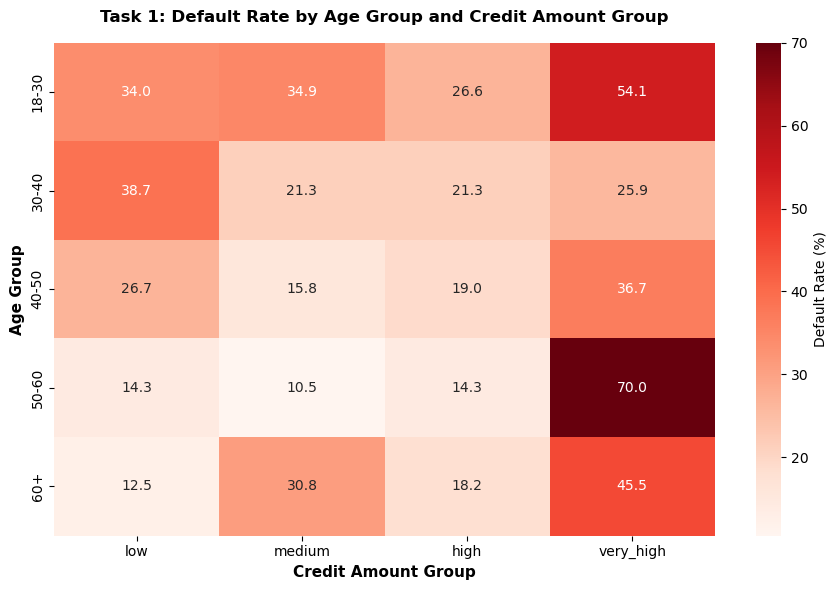

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ['18-30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

credit_labels = ['low', 'medium', 'high', 'very_high']
df['credit_amount_group'] = pd.qcut(df['credit_amount'], q=4, labels=credit_labels)

df['is_bad'] = df['risk_label'].astype(str).str.contains('Bad').astype(int)

default_rate_table = df.pivot_table(
    values='is_bad', 
    index='age_group', 
    columns='credit_amount_group', 
    aggfunc='mean'
) * 100  

print("--- جدول نسبة التخلف لكل فئة (عمر × مبلغ) ---")
display(default_rate_table)

plt.figure(figsize=(9, 6))
sns.heatmap(default_rate_table, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Default Rate (%)'})
plt.title('Task 1: Default Rate by Age Group and Credit Amount Group', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Credit Amount Group', fontsize=11, fontweight='bold')
plt.ylabel('Age Group', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

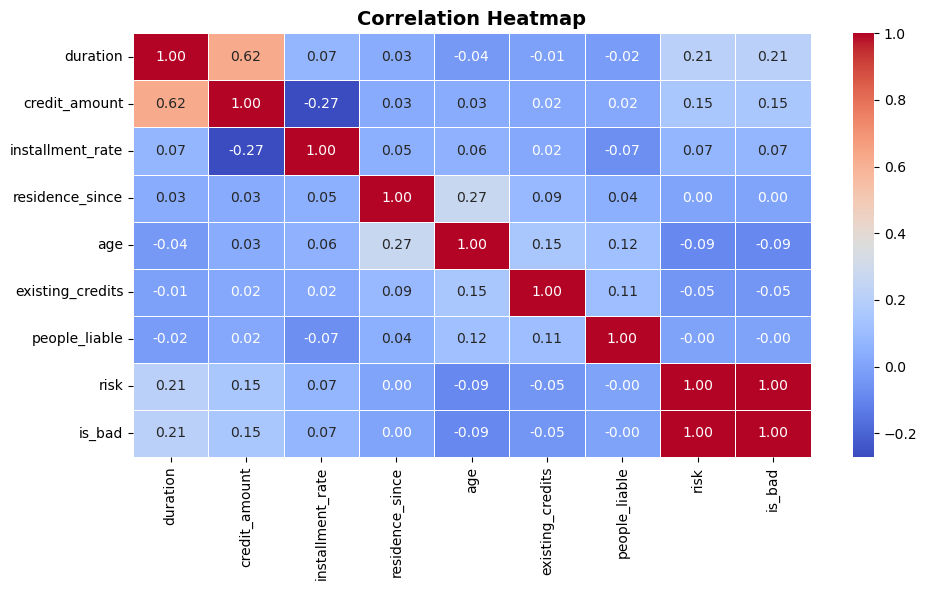

C:\Users\DELL\AppData\Local\Temp\ipykernel_18544\827712817.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_corr.values, y=risk_corr.index, palette="Blues_r")


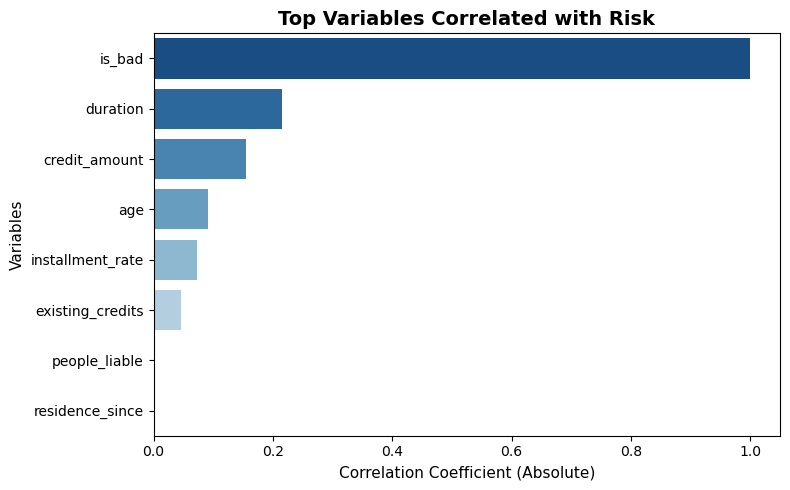

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.figure(figsize=(10, 6))

corr_matrix = df.corr(numeric_only=True)

# رسم الـ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

risk_corr = (
    df.corr(numeric_only=True)["risk"]
    .drop("risk")
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(x=risk_corr.values, y=risk_corr.index, palette="Blues_r")

plt.xlabel("Correlation Coefficient (Absolute)", fontsize=11)
plt.ylabel("Variables", fontsize=11)
plt.title(
    "Top Variables Correlated with Risk", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

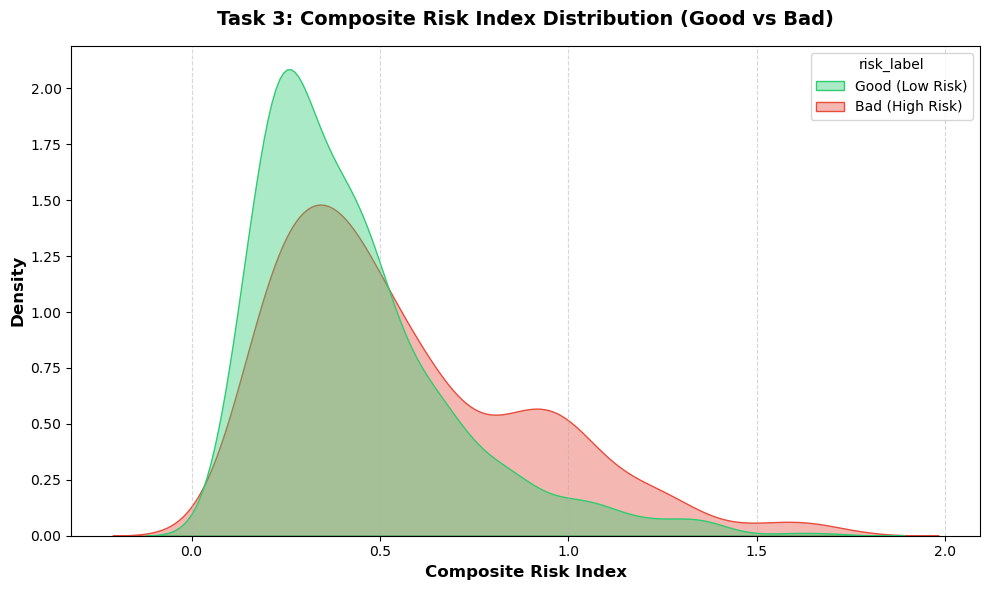

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['composite_risk_index'] = (df['credit_amount'] / df['credit_amount'].max()) + (df['duration'] / df['duration'].max())

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, 
    x='composite_risk_index', 
    hue='risk_label', 
    fill=True, 
    common_norm=False, 
    palette={'Good (Low Risk)': '#2ecc71', 'Bad (High Risk)': '#e74c3c'},
    alpha=0.4
)

plt.title('Task 3: Composite Risk Index Distribution (Good vs Bad)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Composite Risk Index', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

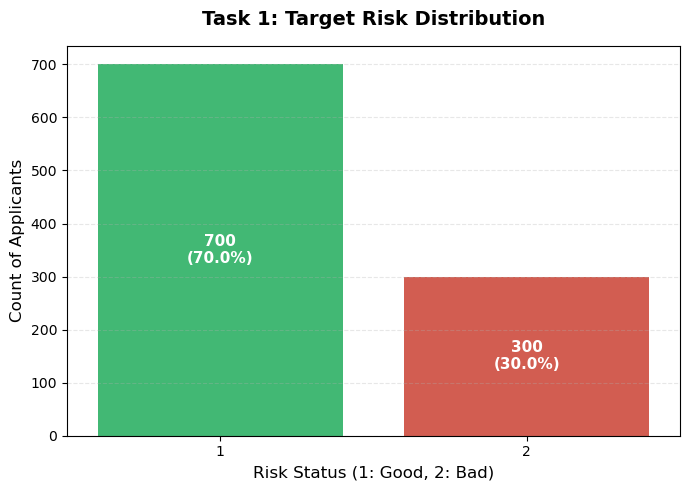

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df, 
    x='risk', 
    hue='risk', 
    palette={1: '#2ecc71', 2: '#e74c3c'},
    legend=False
)

plt.title('Task 1: Target Risk Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Risk Status (1: Good, 2: Bad)', fontsize=12)
plt.ylabel('Count of Applicants', fontsize=12)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    count = int(p.get_height())
    ax.annotate(f'{count}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

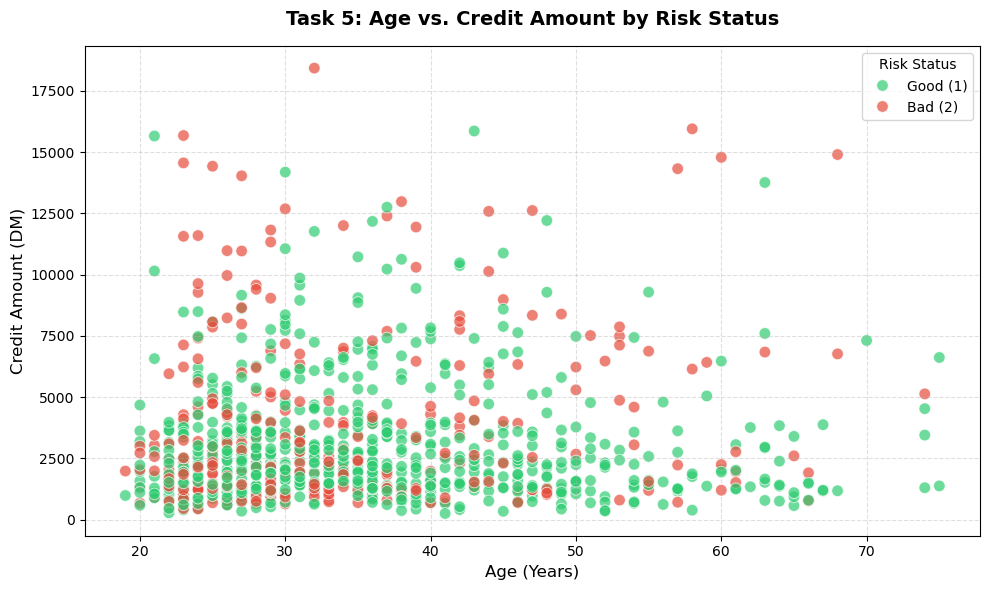

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

df_plot = df.copy()
df_plot['risk_label'] = df_plot['risk'].map({1: 'Good (1)', 2: 'Bad (2)', '1': 'Good (1)', '2': 'Bad (2)'})

sns.scatterplot(
    data=df_plot, 
    x='age', 
    y='credit_amount', 
    hue='risk_label',
    palette={'Good (1)': '#2ecc71', 'Bad (2)': '#e74c3c'}, 
            alpha=0.7,
    s=70,
    edgecolor='w'
)

plt.title('Task 5: Age vs. Credit Amount by Risk Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Credit Amount (DM)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(title='Risk Status')

plt.tight_layout()
plt.show()

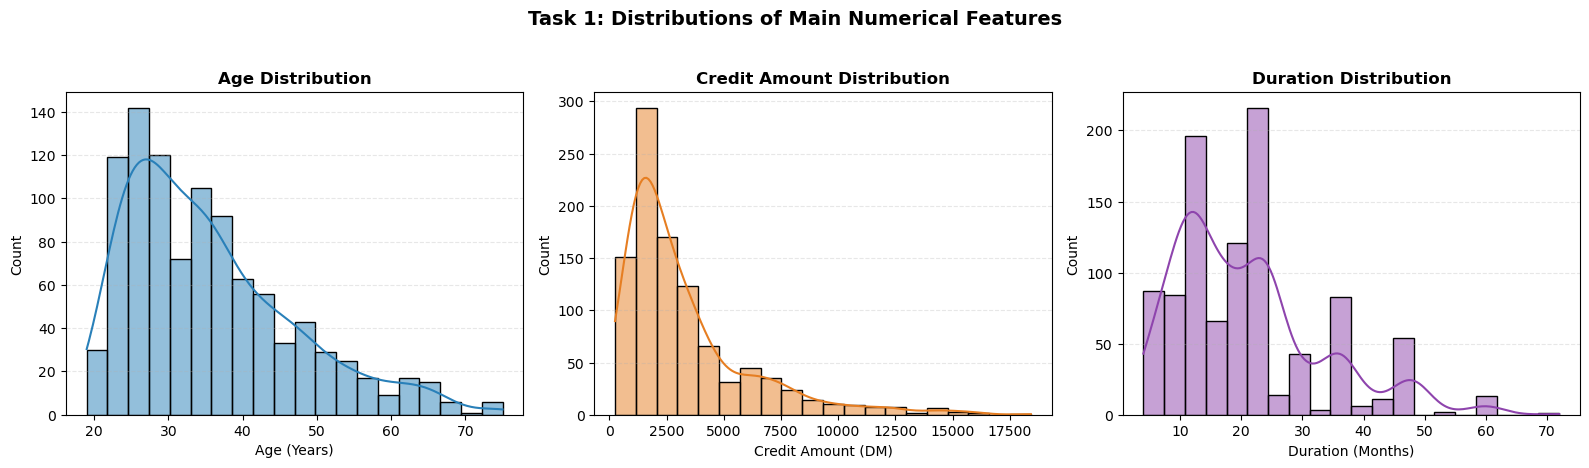

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['age'], kde=True, ax=axes[0], color='#2980b9', bins=20)
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# 2. Credit Amount Distribution
sns.histplot(df['credit_amount'], kde=True, ax=axes[1], color='#e67e22', bins=20)
axes[1].set_title('Credit Amount Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Credit Amount (DM)')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

# 3. Duration Distribution
sns.histplot(df['duration'], kde=True, ax=axes[2], color='#8e44ad', bins=20)
axes[2].set_title('Duration Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Duration (Months)')
axes[2].set_ylabel('Count')
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Task 1: Distributions of Main Numerical Features', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()